In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path().resolve().parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

In [2]:
import sys

import pandas as pd
import matplotlib.pyplot as plt
import logging
import src.logger
from src.data_loader import DataLoader
from src.exception import CustomException
from config.config import DATA_PATH

In [3]:
loader = DataLoader(DATA_PATH)

df = loader.load_data()

2026-07-20 21:29:11,643 - INFO - ============================================================
2026-07-20 21:29:11,645 - INFO - DATA LOADING STARTED
2026-07-20 21:29:11,647 - INFO - ============================================================
2026-07-20 21:29:11,649 - INFO - Dataset Found
2026-07-20 21:29:11,651 - INFO - Dataset is not empty
2026-07-20 21:29:11,682 - INFO - Dataset Loaded Successfully
2026-07-20 21:29:11,685 - INFO - Dataset Shape : (10000, 10)
2026-07-20 21:29:11,687 - INFO - Columns : ['College_ID', 'IQ', 'Prev_Sem_Result', 'CGPA', 'Academic_Performance', 'Internship_Experience', 'Extra_Curricular_Score', 'Communication_Skills', 'Projects_Completed', 'Placement']
2026-07-20 21:29:11,688 - INFO - ============================================================
2026-07-20 21:29:11,689 - INFO - DATA LOADING COMPLETED
2026-07-20 21:29:11,691 - INFO - ============================================================


In [4]:
logging.info("Displaying First Five Rows")

df.head()

2026-07-20 21:29:12,841 - INFO - Displaying First Five Rows


,College_ID,IQ,Prev_Sem_Result,CGPA,Academic_Performance,Internship_Experience,Extra_Curricular_Score,Communication_Skills,Projects_Completed,Placement
0,CLG0030,107,6.61,6.28,8,No,8,8,4,No
1,CLG0061,97,5.52,5.37,8,No,7,8,0,No
2,CLG0036,109,5.36,5.83,9,No,3,1,1,No
3,CLG0055,122,5.47,5.75,6,Yes,1,6,1,No
4,CLG0004,96,7.91,7.69,7,No,8,10,2,No


In [5]:
logging.info("Displaying Last Five Rows")

df.tail()

2026-07-20 21:29:13,951 - INFO - Displaying Last Five Rows


,College_ID,IQ,Prev_Sem_Result,CGPA,Academic_Performance,Internship_Experience,Extra_Curricular_Score,Communication_Skills,Projects_Completed,Placement
9995,CLG0021,119,8.41,8.29,4,No,1,8,0,Yes
9996,CLG0098,70,9.25,9.34,7,No,0,7,2,No
9997,CLG0066,89,6.08,6.25,3,Yes,3,9,5,No
9998,CLG0045,107,8.77,8.92,3,No,7,5,1,No
9999,CLG0060,109,9.41,9.77,8,No,3,5,5,No


In [6]:
logging.info("Checking Dataset Shape")

logging.info(df.shape)

2026-07-20 21:29:14,912 - INFO - Checking Dataset Shape
2026-07-20 21:29:14,915 - INFO - (10000, 10)


In [7]:
logging.info("Checking Dataset Information")

df.info()

2026-07-20 21:29:15,817 - INFO - Checking Dataset Information


<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   College_ID              10000 non-null  str    
 1   IQ                      10000 non-null  int64  
 2   Prev_Sem_Result         10000 non-null  float64
 3   CGPA                    10000 non-null  float64
 4   Academic_Performance    10000 non-null  int64  
 5   Internship_Experience   10000 non-null  str    
 6   Extra_Curricular_Score  10000 non-null  int64  
 7   Communication_Skills    10000 non-null  int64  
 8   Projects_Completed      10000 non-null  int64  
 9   Placement               10000 non-null  str    
dtypes: float64(2), int64(5), str(3)
memory usage: 894.3 KB


In [8]:
logging.info("Checking Statistical Summary")

df.describe()

2026-07-20 21:29:16,892 - INFO - Checking Statistical Summary


,IQ,Prev_Sem_Result,CGPA,Academic_Performance,Extra_Curricular_Score,Communication_Skills,Projects_Completed
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,99.471800,7.535673,7.532379,5.546400,4.970900,5.561800,2.513400
std,15.053101,1.447519,1.470141,2.873477,3.160103,2.900866,1.715959
min,41.000000,5.000000,4.540000,1.000000,0.000000,1.000000,0.000000
25%,89.000000,6.290000,6.290000,3.000000,2.000000,3.000000,1.000000
50%,99.000000,7.560000,7.550000,6.000000,5.000000,6.000000,3.000000
75%,110.000000,8.790000,8.770000,8.000000,8.000000,8.000000,4.000000
max,158.000000,10.000000,10.460000,10.000000,10.000000,10.000000,5.000000


In [9]:
logging.info("Checking Duplicate Values")

print(df.duplicated().sum())

2026-07-20 21:29:17,700 - INFO - Checking Duplicate Values


0


In [10]:
logging.info("Checking Data Types")

df.dtypes

2026-07-20 21:29:18,513 - INFO - Checking Data Types


College_ID                    str
IQ                          int64
Prev_Sem_Result           float64
CGPA                      float64
Academic_Performance        int64
Internship_Experience         str
Extra_Curricular_Score      int64
Communication_Skills        int64
Projects_Completed          int64
Placement                     str
dtype: object

# Univariate Analysis

In [11]:
logging.info("Target Variable Distribution")

df["Placement"].value_counts()

2026-07-20 21:29:20,479 - INFO - Target Variable Distribution


Placement
No     8341
Yes    1659
Name: count, dtype: int64

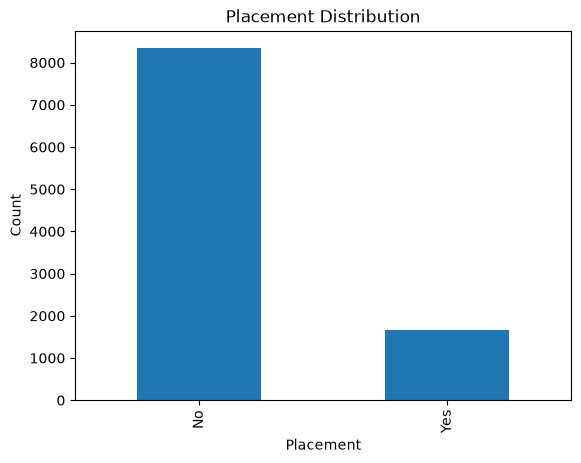

In [12]:
df["Placement"].value_counts().plot(kind="bar")

plt.title("Placement Distribution")
plt.xlabel("Placement")
plt.ylabel("Count")

plt.show()

# Feature Distribution

In [13]:
numeric_columns = df.select_dtypes(include="number").columns

numeric_columns

Index(['IQ', 'Prev_Sem_Result', 'CGPA', 'Academic_Performance',
       'Extra_Curricular_Score', 'Communication_Skills', 'Projects_Completed'],
      dtype='str')

2026-07-20 21:29:23,451 - INFO - Plotting Histogram : IQ


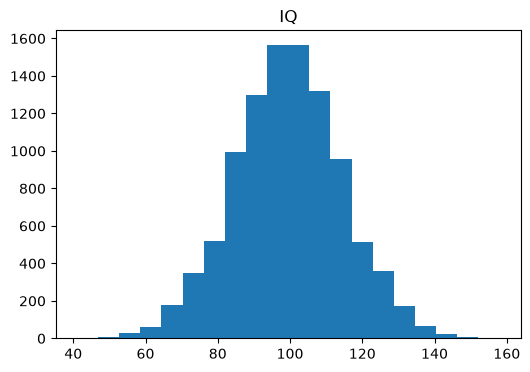

2026-07-20 21:29:23,611 - INFO - Plotting Histogram : Prev_Sem_Result


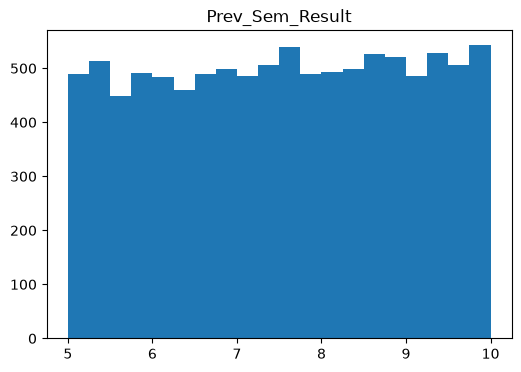

2026-07-20 21:29:23,724 - INFO - Plotting Histogram : CGPA


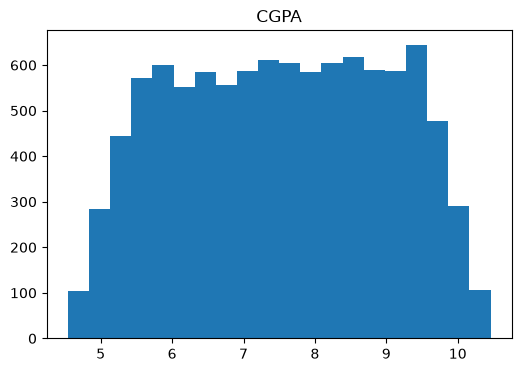

2026-07-20 21:29:23,843 - INFO - Plotting Histogram : Academic_Performance


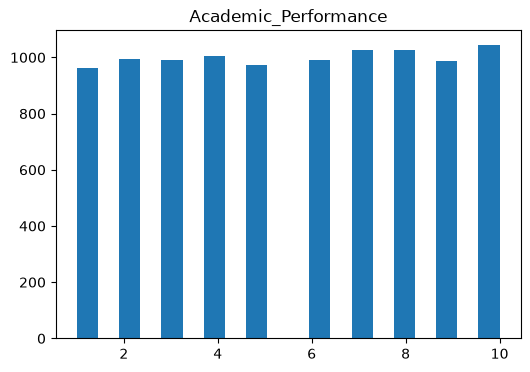

2026-07-20 21:29:23,941 - INFO - Plotting Histogram : Extra_Curricular_Score


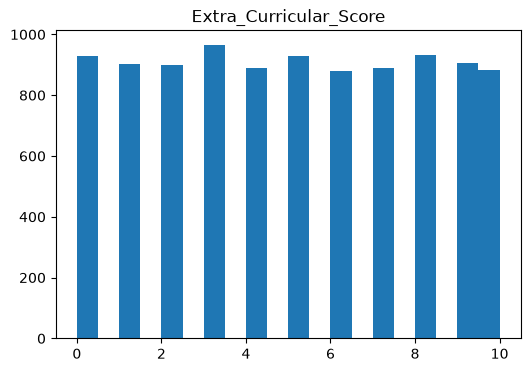

2026-07-20 21:29:24,082 - INFO - Plotting Histogram : Communication_Skills


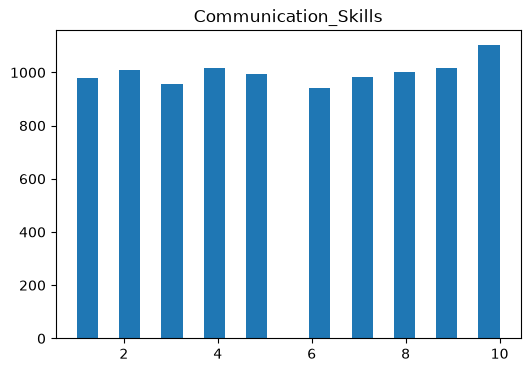

2026-07-20 21:29:24,181 - INFO - Plotting Histogram : Projects_Completed


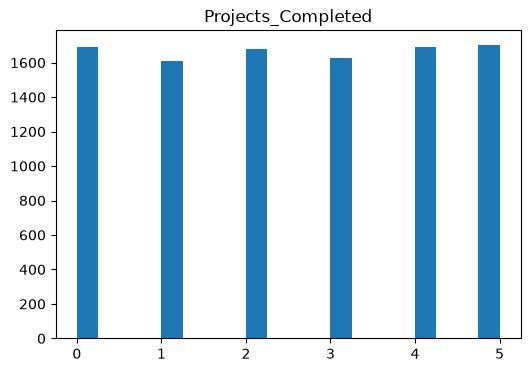

In [14]:
for column in numeric_columns:

    logging.info(f"Plotting Histogram : {column}")

    plt.figure(figsize=(6,4))

    plt.hist(df[column], bins=20)

    plt.title(column)

    plt.show()

# Correlation

In [15]:
logging.info("Calculating Correlation")

correlation = df.corr(numeric_only=True)

correlation

2026-07-20 21:29:25,694 - INFO - Calculating Correlation


,IQ,Prev_Sem_Result,CGPA,Academic_Performance,Extra_Curricular_Score,Communication_Skills,Projects_Completed
IQ,1.000000,-0.002640,-0.002859,-0.006827,-0.003458,-0.010896,0.014538
Prev_Sem_Result,-0.002640,1.000000,0.980768,-0.005765,0.009326,-0.017269,0.018434
CGPA,-0.002859,0.980768,1.000000,-0.002958,0.011441,-0.018242,0.020872
Academic_Performance,-0.006827,-0.005765,-0.002958,1.000000,0.011774,-0.019733,-0.013148
Extra_Curricular_Score,-0.003458,0.009326,0.011441,0.011774,1.000000,0.003769,0.008122
Communication_Skills,-0.010896,-0.017269,-0.018242,-0.019733,0.003769,1.000000,-0.004486
Projects_Completed,0.014538,0.018434,0.020872,-0.013148,0.008122,-0.004486,1.000000


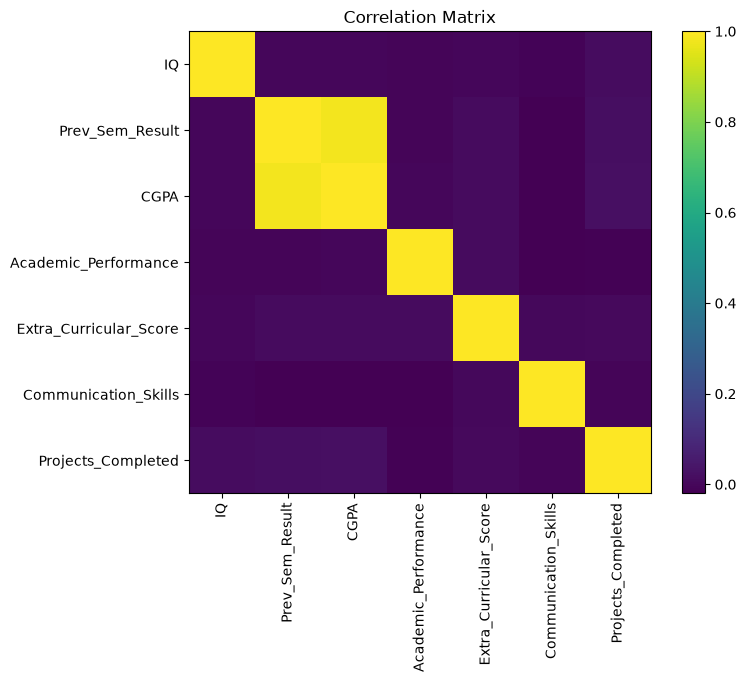

In [16]:
plt.figure(figsize=(8,6))

plt.imshow(correlation)

plt.colorbar()

plt.xticks(range(len(correlation.columns)), correlation.columns, rotation=90)

plt.yticks(range(len(correlation.columns)), correlation.columns)

plt.title("Correlation Matrix")

plt.show()

# Feature vs Target

In [17]:
placement_counts = df.groupby("Placement")["CGPA"].mean()

placement_counts

Placement
No     7.321527
Yes    8.592483
Name: CGPA, dtype: float64

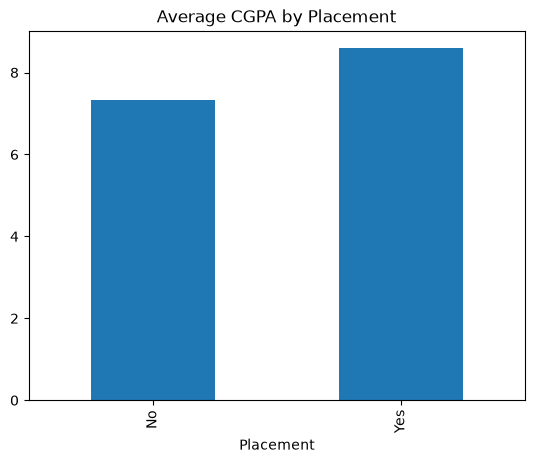

In [18]:
placement_counts.plot(kind="bar")

plt.title("Average CGPA by Placement")

plt.show()

In [19]:
logging.info("=" * 60)
logging.info("EDA COMPLETED SUCCESSFULLY")
logging.info("=" * 60)

print("EDA Completed Successfully")

2026-07-20 21:29:29,419 - INFO - ============================================================
2026-07-20 21:29:29,422 - INFO - EDA COMPLETED SUCCESSFULLY
2026-07-20 21:29:29,424 - INFO - ============================================================


EDA Completed Successfully
